In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

from core import make_data, loss, optimal
from opt import gd, sgd, hf, cost_to_eps, acc_at_budget

%matplotlib inline

In [2]:
N, d   = 100, 20
kappas = np.logspace(0, 4, 9)
noises = [0.0, 0.1]

run_budget = 100_000
cost_val   = [1e2, 1e4]
eps_val    = [1e-2, 1e-6]
cg_tol     = 1e-8

assert max(cost_val) <= run_budget

color = {"HF": "#2a78d6", "GD": "#eb6834", "SGD": "#1baf7a"}
dash  = {"HF": "solid", "GD": (0, (6, 2)), "SGD": (0, (1.5, 2.2))}
mark  = {"HF": "o", "GD": "s", "SGD": "D"}
zord  = {"HF": 4, "GD": 5, "SGD": 6}
order = ["HF", "GD", "SGD"]
ink, muted, grid_c, surface = "#1a1a19", "#6b6b68", "#e4e4e1", "#fcfcfb"

pd.set_option("display.max_rows", 100)

In [3]:
_SUP = dict(zip("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹"))


def eps_txt(e):
    return "10" + "".join(_SUP[c] for c in str(int(round(np.log10(e)))))


def eps_tex(e):
    return "$10^{%d}$" % int(round(np.log10(e)))


def eigen_range(X):
    ev = np.linalg.eigvalsh((X.T @ X) / X.shape[0])
    return ev[0], ev[-1]


def prep(noise, kappa):
    X, y, _ = make_data(N, d, kappa, noise=noise)
    _, L_star = optimal(X, y)
    L0 = loss(np.zeros(d), X, y)
    lmin, lmax = eigen_range(X)
    lmin_sgd = None if noise == 0.0 else lmin
    t0 = time.perf_counter()
    _, st = sgd(X, y, budget=1.0, eps_floor=0.0, L_star=L_star,
                lmax=lmax, lmin=lmin_sgd)
    return {"X": X, "y": y, "L0": L0, "L_star": L_star,
            "lr_gd": 2.0 / (lmin + lmax), "lr_sgd": st["lr"], "batch": st["batch"],
            "lmin_sgd": lmin_sgd, "tune_s": time.perf_counter() - t0}


def run_one(P, m, budget, eps_floor):
    t0 = time.perf_counter()
    if m == "HF":
        _, st = hf(P["X"], P["y"], budget=budget, eps_floor=eps_floor,
                   L_star=P["L_star"], cg_tol=cg_tol)
    elif m == "GD":
        _, st = gd(P["X"], P["y"], P["lr_gd"], budget=budget, eps_floor=eps_floor,
                   L_star=P["L_star"])
    else:
        _, st = sgd(P["X"], P["y"], lr=P["lr_sgd"], batch=P["batch"], budget=budget,
                    eps_floor=eps_floor, L_star=P["L_star"], lmin=P["lmin_sgd"])
    st["seconds"] = time.perf_counter() - t0
    st["L0"], st["L_star"] = P["L0"], P["L_star"]
    return st


def readout(kind, st, lv):
    if kind == "cap":
        return max(acc_at_budget(st["trace"], st["L0"], st["L_star"], lv), 0.0), False
    c = cost_to_eps(st["trace"], st["L0"], st["L_star"], lv)
    return (run_budget if c is None else c), (c is None)


def style(ax, title, xlab=True, ylab=None, ylog=True):
    ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.set_facecolor(surface)
    ax.set_title(title, fontsize=10, color=ink, pad=6, loc="left")
    if xlab: ax.set_xlabel("κ", fontsize=9, color=muted)
    if ylab: ax.set_ylabel(ylab, fontsize=9, color=muted)
    ax.grid(True, which="major", color=grid_c, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", color=grid_c, linewidth=0.4, alpha=0.5, zorder=0)
    ax.tick_params(colors=muted, labelsize=8)
    for s in ax.spines.values(): s.set_color(grid_c)


def method_handles(censor=False):
    h = [plt.Line2D([], [], color=color[m], linewidth=2, linestyle=dash[m],
                    marker=mark[m], markersize=5, markeredgecolor=surface, label=lbl)
         for m, lbl in [("HF", "HF (Newton+CG)"), ("GD", "GD (full batch)"),
                        ("SGD", "SGD (batch=%d)" % BATCH)]]
    if censor:
        h.append(plt.Line2D([], [], color=muted, linestyle="none", marker="^",
                            markerfacecolor=surface, markeredgecolor=muted,
                            markersize=7, label="never reached (>= %s)" % f"{run_budget:,}"))
    return h


def block_table(kind, noise):
    levels = cost_val if kind == "cap" else eps_val
    lname  = "C" if kind == "cap" else "ε"
    idx, data = [], []
    for lv in levels:
        for k in kappas:
            rec = {}
            for m in order:
                st = runs[(kind, noise, k, m, lv)]
                v, cen = readout(kind, st, lv)
                if kind == "cap":
                    rec[m] = "<1e-16" if v < 1e-16 else f"{v:.2e}"
                else:
                    rec[m] = f"{v:,.0f}*" if cen else f"{v:,.0f}"
                rec[m + "_s"] = f"{st['seconds']:.3f}"
            idx.append((f"{lv:g}" if kind == "cap" else eps_txt(lv), f"{k:,.0f}"))
            data.append(rec)
    cols = [c for m in order for c in (m, m + "_s")]
    df = pd.DataFrame(data, index=pd.MultiIndex.from_tuples(idx, names=[lname, "kappa"]))
    return df[cols]


def _line(ax, ks, v, m, cen=None):
    z = zord[m]
    ax.plot(ks, v, color=color[m], linewidth=2, linestyle=dash[m], zorder=z)
    if cen is None:
        cen = np.zeros(len(ks), dtype=bool)
    ax.plot(ks[~cen], v[~cen], mark[m], color=color[m], markersize=5,
            markeredgecolor=surface, markeredgewidth=1.2, zorder=z + 0.5)
    if cen.any():
        ax.plot(ks[cen], v[cen], "^", color=surface, markersize=8,
                markeredgecolor=color[m], markeredgewidth=1.5, zorder=z + 0.5)


def plot_cap(noise):
    ks = np.asarray(kappas)
    fig, axes = plt.subplots(1, len(cost_val), figsize=(12, 4.6), sharey=True)
    fig.patch.set_facecolor(surface)
    for j, lv in enumerate(cost_val):
        ax = axes[j]
        for m in order:
            v = np.array([max(readout("cap", runs[("cap", noise, k, m, lv)], lv)[0], 1e-17)
                          for k in ks])
            _line(ax, ks, v, m)
        for e in eps_val:
            ax.axhline(e, color=muted, linewidth=0.8, linestyle=(0, (2, 3)), zorder=1)
        style(ax, f"C = {lv:,.0f}", ylab="Loss" if j == 0 else None)
    fig.legend(handles=method_handles(), loc="lower center", ncol=3, frameon=False, fontsize=9)
    fig.suptitle(f"Loss left after C gradient-equivalents  ·  noise = {noise}",
                 fontsize=13, color=ink, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0.09, 1, 0.92])
    plt.show()


def plot_tol(noise, metric):
    ks = np.asarray(kappas)
    ylab = "cost  (grad-equiv)" if metric == "cost" else "time  (s)"
    fig, axes = plt.subplots(1, len(eps_val), figsize=(12, 4.6), sharey=True)
    fig.patch.set_facecolor(surface)
    for j, lv in enumerate(eps_val):
        ax = axes[j]
        for m in order:
            sts = [runs[("tol", noise, k, m, lv)] for k in ks]
            cen = np.array([readout("tol", st, lv)[1] for st in sts], dtype=bool)
            v = np.array([readout("tol", st, lv)[0] if metric == "cost"
                          else max(st["seconds"], 1e-5) for st in sts])
            _line(ax, ks, v, m, cen)
        if metric == "cost":
            ax.axhline(run_budget, color=muted, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
        style(ax, f"ε = {eps_tex(lv)}", ylab=ylab if j == 0 else None)
    fig.legend(handles=method_handles(censor=True), loc="lower center",
               ncol=4, frameon=False, fontsize=9)
    fig.suptitle(f"{'Cost' if metric == 'cost' else 'Wall time'} to reach ε  ·  noise = {noise}",
                 fontsize=13, color=ink, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0.09, 1, 0.92])
    plt.show()

In [4]:
runs = {}
t_all = time.perf_counter()

for noise in noises:
    for kappa in kappas:
        P = prep(noise, kappa)
        BATCH = P["batch"]
        line = f"noise={noise} k={kappa:>9.1f}  (sgd lr={P['lr_sgd']:.3g}, tune {P['tune_s']:.2f}s)"
        for m in order:
            for lv in cost_val:
                runs[("cap", noise, kappa, m, lv)] = run_one(P, m, lv, 0.0)
            for lv in eps_val:
                runs[("tol", noise, kappa, m, lv)] = run_one(P, m, run_budget, lv)
            tot = sum(runs[(kd, noise, kappa, m, lv)]["seconds"]
                      for kd, lvs in (("cap", cost_val), ("tol", eps_val)) for lv in lvs)
            line += f"  {m}={tot:.2f}s"
        print(line)

print(f"\n{len(runs)} runs, total {time.perf_counter() - t_all:.1f}s")

noise=0.0 k=      1.0  (sgd lr=0.25, tune 0.02s)  HF=0.00s  GD=0.00s  SGD=0.00s
noise=0.0 k=      3.2  (sgd lr=0.158, tune 0.02s)  HF=0.00s  GD=0.00s  SGD=0.00s
noise=0.0 k=     10.0  (sgd lr=0.1, tune 0.11s)  HF=0.00s  GD=0.00s  SGD=0.00s
noise=0.0 k=     31.6  (sgd lr=0.0316, tune 0.02s)  HF=0.00s  GD=0.01s  SGD=0.01s


noise=0.0 k=    100.0  (sgd lr=0.015, tune 0.04s)  HF=0.00s  GD=0.02s  SGD=0.02s


noise=0.0 k=    316.2  (sgd lr=0.00474, tune 0.08s)  HF=0.00s  GD=0.12s  SGD=0.06s


noise=0.0 k=   1000.0  (sgd lr=0.0015, tune 0.19s)  HF=0.00s  GD=0.16s  SGD=0.14s


noise=0.0 k=   3162.3  (sgd lr=0.000474, tune 0.41s)  HF=0.00s  GD=0.31s  SGD=0.42s


...

noise=0.1 k=    100.0  (sgd lr=0.01, tune 0.09s)  HF=0.00s  GD=0.02s  SGD=1.18s


noise=0.1 k=    316.2  (sgd lr=0.00316, tune 0.17s)  HF=0.08s  GD=0.13s  SGD=1.30s


noise=0.1 k=   1000.0  (sgd lr=0.001, tune 0.31s)  HF=0.01s  GD=0.15s  SGD=1.32s


noise=0.1 k=   3162.3  (sgd lr=0.000474, tune 0.40s)  HF=0.00s  GD=0.26s  SGD=2.20s


noise=0.1 k=  10000.0  (sgd lr=0.0001, tune 0.51s)  HF=0.00s  GD=0.60s  SGD=3.09s

216 runs, total 19.2s


# 1. Clean data — noise = 0

Optimum is exact: $y = Xw_{\text{true}}$, so $L^{*} = 0$ and every mini-batch
gradient goes quiet at $w^{*}$. Curvature is the only thing separating the methods here.

## 1a. Fixed cost limit — stop at `C`

Each run is capped at `C` gradient-equivalents, then we read the loss it was left at.
Lower is better. Dotted lines mark the `eps` levels used in part b.

HF   HF_s        GD   GD_s       SGD  SGD_s
C     kappa                                                  
100   1       <1e-16  0.000    <1e-16  0.000    <1e-16  0.001
      3       <1e-16  0.000    <1e-16  0.001    <1e-16  0.001
      10      <1e-16  0.001    <1e-16  0.001    <1e-16  0.002
      32      <1e-16  0.001  3.25e-07  0.001    <1e-16  0.006
      100     <1e-16  0.001  2.61e-03  0.001  6.61e-16  0.007
      316     <1e-16  0.001  5.40e-02  0.001  7.04e-08  0.008
      1,000   <1e-16  0.001  1.64e-01  0.001  1.99e-05  0.006
      3,162   <1e-16  0.001  2.64e-01  0.002  1.22e-03  0.006
      10,000  <1e-16  0.001  3.42e-01  0.001  4.66e-03  0.006
10000 1       <1e-16  0.000    <1e-16  0.000    <1e-16  0.001
      3       <1e-16  0.000    <1e-16  0.001    <1e-16  0.001
      10      <1e-16  0.001    <1e-16  0.002    <1e-16  0.002
      32      <1e-16  0.001    <1e-16  0.006    <1e-16  0.006
      100     <1e-16  0.001    <1e-16  0.018    <1e-16  0.015
      316     <1e-16  0.001    <1e-16  0.111    <1e-16  0.046
      1,000   <1e-16  0.001    <1e-16  0.111    <1e-16  0.121
      3,162   <1e-16  0.001  9.45e-07  0.170    <1e-16  0.387
      10,000  <1e-16  0.001  6.43e-03  0.112    <1e-16  0.685

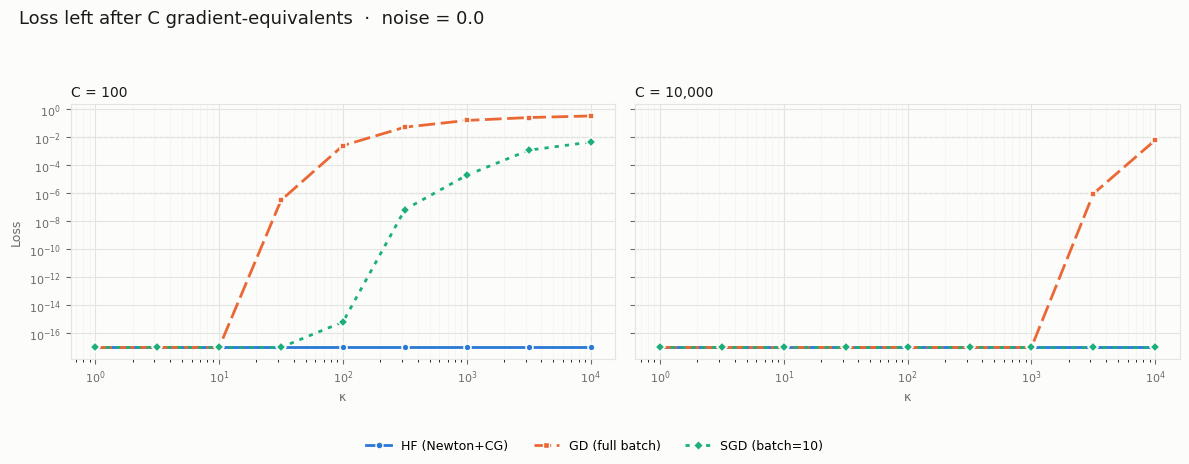

In [5]:
display(block_table("cap", noises[0]))
plot_cap(noises[0])

## 1b. Fixed error tolerance — stop at `eps`

Same runs turned around: fix the accuracy target, measure what it takes to get there.
Two figures — first the cost, then the wall time, both against κ.
`*` (and the hollow triangle) = never reached inside `run_budget`, so that number
is a lower bound, not a measurement.

HF   HF_s      GD   GD_s    SGD  SGD_s
ε    kappa                                         
10⁻² 1        2  0.000       1  0.000      2  0.000
     3        3  0.000       3  0.000      2  0.000
     10       5  0.000       6  0.000      2  0.000
     32       7  0.000      20  0.000      4  0.000
     100      8  0.000      67  0.001      5  0.000
     316      9  0.000     233  0.003      8  0.001
     1,000    9  0.000     795  0.009      9  0.001
     3,162    8  0.001   2,675  0.030      9  0.001
     10,000   8  0.001   8,897  0.100      9  0.001
10⁻⁶ 1        2  0.000       1  0.000      5  0.000
     3        7  0.000       9  0.000      5  0.000
     10      11  0.000      28  0.000      6  0.000
     32      15  0.000      92  0.001     14  0.001
     100     17  0.000     297  0.003     28  0.002
     316     19  0.000     961  0.010     71  0.004
     1,000   23  0.000   3,097  0.035    167  0.010
     3,162   26  0.001   9,956  0.111    423  0.026
     10,000  28  0.001  31,923  0.356  1,036  0.064

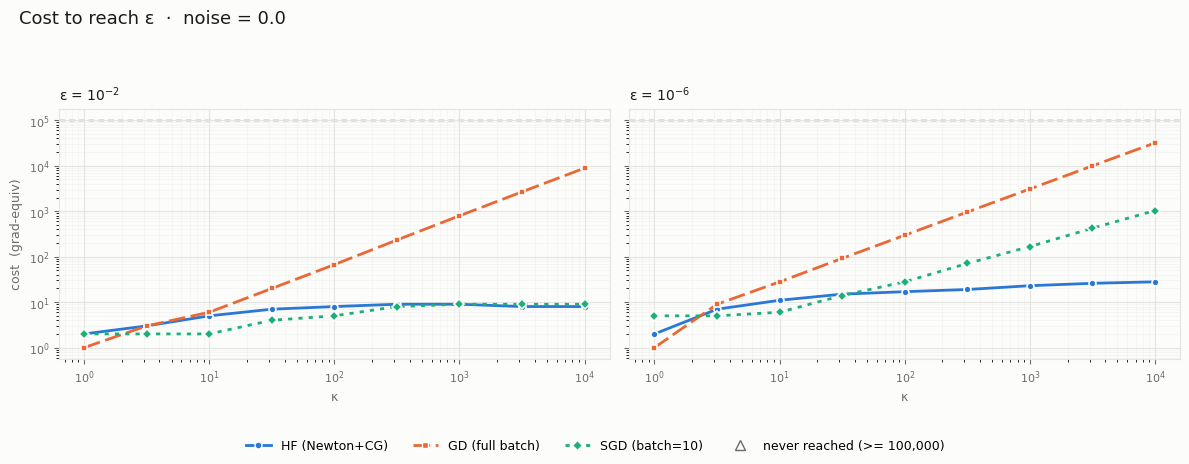

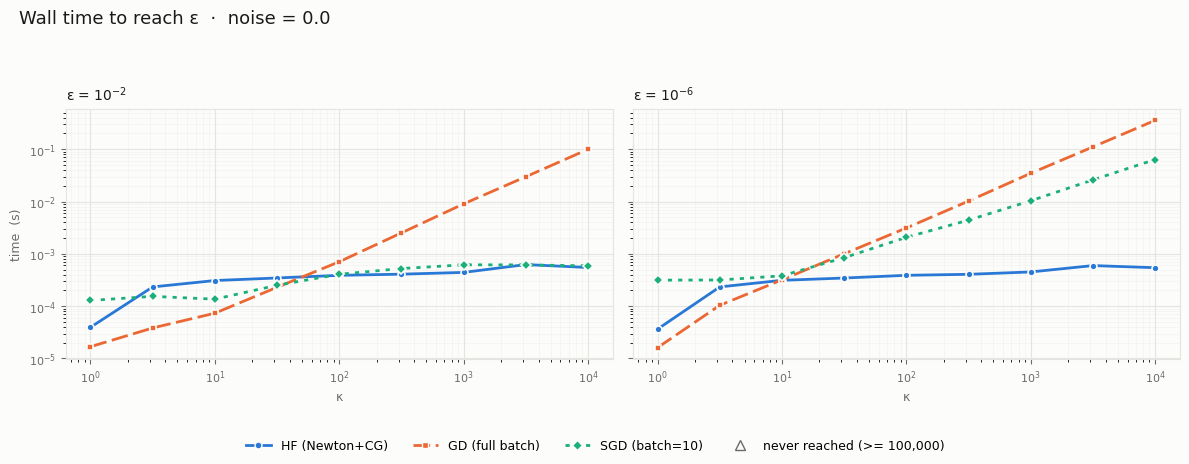

In [6]:
display(block_table("tol", noises[0]))
plot_tol(noises[0], "cost")
plot_tol(noises[0], "time")

# 2. Noisy data — sigma = 0.1

$y = Xw_{\text{true}} + \sigma\,\mathrm{std}(y)\,\epsilon$. The Hessian
$H = X^{\top}X/n$ is untouched, so $\kappa$ is identical to section 1 — but
$L^{*} > 0$ and the mini-batch gradients stay noisy at the optimum. If HF's edge is
curvature it should carry over unchanged; SGD is the one that should degrade.

## 2a. Fixed cost limit — stop at `C`

HF   HF_s        GD   GD_s       SGD  SGD_s
C     kappa                                                  
100   1       <1e-16  0.000    <1e-16  0.000  1.21e-05  0.006
      3       <1e-16  0.002    <1e-16  0.000  1.71e-05  0.006
      10      <1e-16  0.001    <1e-16  0.001  3.43e-05  0.006
      32      <1e-16  0.000  3.79e-07  0.001  7.27e-05  0.006
      100     <1e-16  0.001  2.97e-03  0.001  1.63e-04  0.006
      316     <1e-16  0.002  6.01e-02  0.001  4.23e-04  0.006
      1,000   <1e-16  0.002  1.79e-01  0.002  9.06e-04  0.006
      3,162   <1e-16  0.001  2.85e-01  0.001  3.52e-03  0.006
      10,000  <1e-16  0.001  3.65e-01  0.001  4.50e-03  0.006
10000 1       <1e-16  0.000    <1e-16  0.000  1.92e-07  0.659
      3       <1e-16  0.002    <1e-16  0.000  2.62e-07  0.626
      10      <1e-16  0.001    <1e-16  0.001  5.01e-07  0.684
      32      <1e-16  0.000    <1e-16  0.003  6.60e-07  0.709
      100     <1e-16  0.001    <1e-16  0.011  8.30e-07  0.830
      316     <1e-16  0.079    <1e-16  0.111  1.37e-06  0.690
      1,000   <1e-16  0.004    <1e-16  0.107  5.09e-06  0.639
      3,162   <1e-16  0.001  1.02e-06  0.123  2.90e-05  0.638
      10,000  <1e-16  0.001  6.88e-03  0.111  7.85e-05  0.623

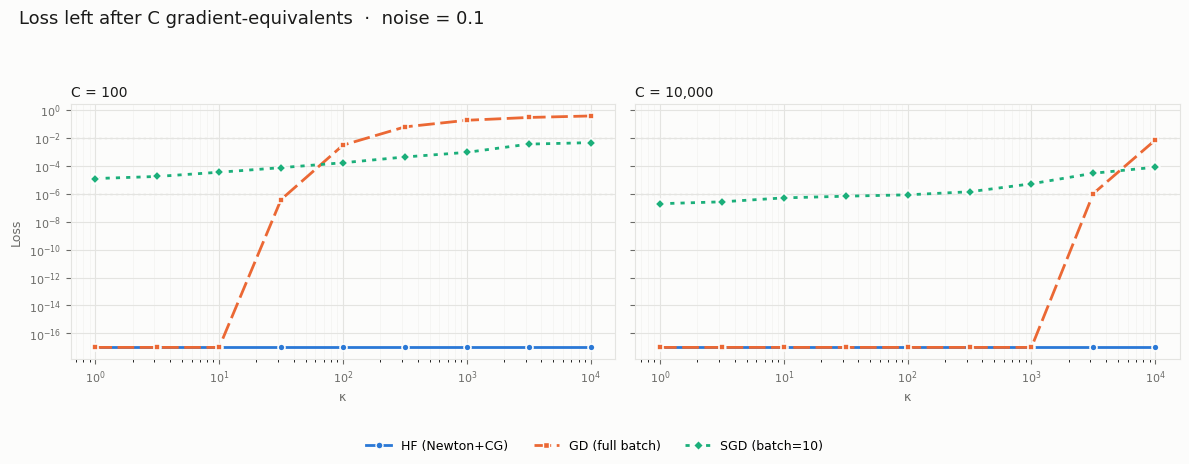

In [7]:
display(block_table("cap", noises[1]))
plot_cap(noises[1])

## 2b. Fixed error tolerance — stop at `eps`

HF   HF_s      GD   GD_s     SGD  SGD_s
ε    kappa                                          
10⁻² 1        2  0.000       1  0.000       2  0.000
     3        3  0.000       3  0.000       2  0.000
     10       5  0.000       7  0.000       3  0.000
     32       6  0.000      21  0.000       3  0.000
     100      8  0.000      70  0.001       5  0.000
     316      9  0.000     241  0.003       9  0.001
     1,000    9  0.000     818  0.008      12  0.002
     3,162    8  0.000   2,737  0.029      13  0.001
     10,000   8  0.001   9,065  0.104      12  0.001
10⁻⁶ 1        2  0.000       1  0.000     619  0.038
     3        7  0.000       9  0.000   2,594  0.161
     10      11  0.000      29  0.000   2,453  0.155
     32      15  0.000      93  0.001   2,451  0.159
     100     17  0.000     300  0.003   5,488  0.340
     316     19  0.000     969  0.011   6,345  0.603
     1,000   22  0.000   3,120  0.033  11,060  0.677
     3,162   24  0.000  10,018  0.111  24,850  1.549
     10,000  26  0.001  32,091  0.379  40,362  2.465

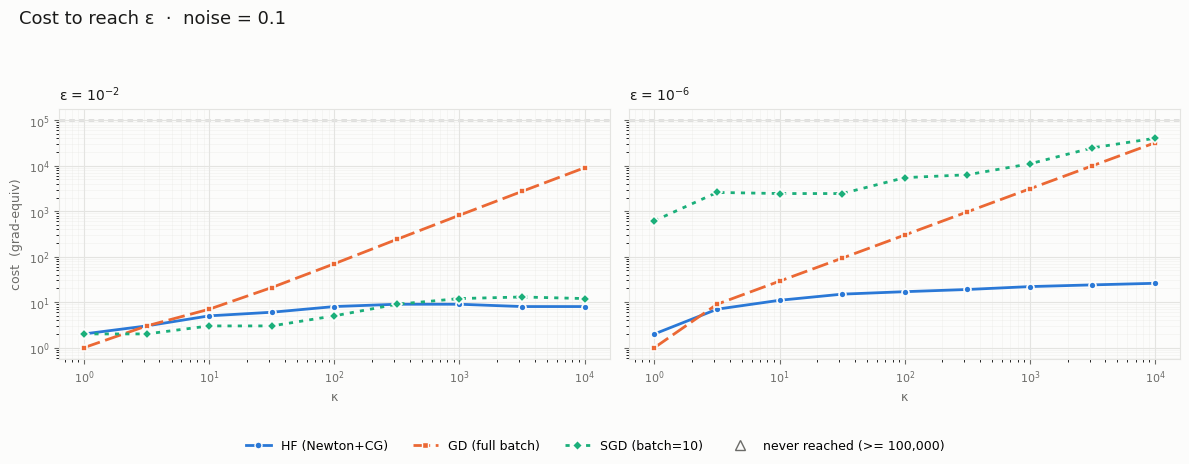

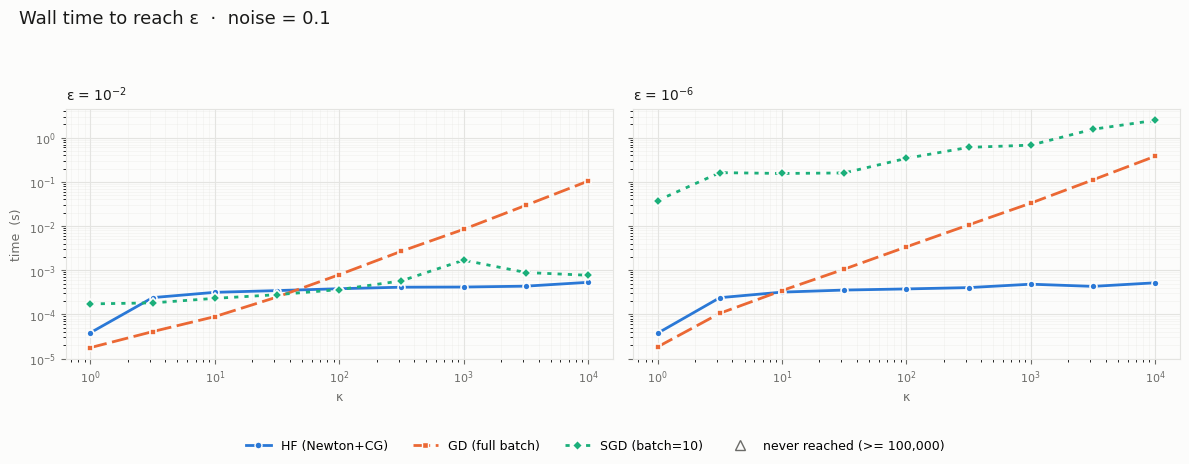

In [8]:
display(block_table("tol", noises[1]))
plot_tol(noises[1], "cost")
plot_tol(noises[1], "time")